In [1]:
import marker_utils
import scanpy as sc
import marker_utils.save_data as save_data

Before inputting the scATAC-seq data, it must be preprocessed. We have provided a preprocessing script for this purpose.

python atac_processed.py --input atac_data_path --fpeak 0.05 --output ./

In [2]:
# Ensure that the obs in the data contains a celltype entry to indicate the cluster to which each cell belongs. 
# Additionally, the obsm should include a spatial entry to provide spatial information.
sc.read_h5ad('example_data/spatial_atac.h5ad')

AnnData object with n_obs × n_vars = 2129 × 37475
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoR

In [3]:
# Run with the default parameters.
info,adata=marker_utils.get_spatial_MarkersEI('example_data/spatial_atac.h5ad')

------Loading data------
------Data transposition------
2129 cells, 37475 genes.
------Step1: Calculate PCA------
------Step2: Calculate the similarity matrix------
------Step3: Adjust the expression value------
------Step4: Calculate EI------


cluster:Subpallium_2runningcalculate_smoothness(2/6):  57%|▌| 8/14 [3:56:55<3:01

cluster:Basal_plate_of_hindbrainrunningcalculate_EI(6/6): 100%|█| 14/14 [6:12:49


19.45 seconds used for calculate_mean_and_var.
21344.04 seconds used for calculate_smoothness.
30.24 seconds used for calculate_V.
125.21 seconds used for calculate_prop.
838.83 seconds used for calculate_local_mean_max.
10.49 seconds used for calculate_EI.
------Congratulations, success!------


In [4]:
# Print the first six Features.
six_features=info['Subpallium_1'].sort_values(by='EI', ascending=False).head(6)['Features'].tolist()
info['Subpallium_1'].sort_values(by='EI', ascending=False).head(6).reset_index(drop=True)

,Features,Mean,Smoothness,Local_max,V,Prop,Prop_sum,P,EI
0,chr14:22046124-22046625,1.738804,0.018733,0.976468,161.396620,1.686066e+26,7.505573e+05,0.100000,1.513867e-02
1,chr7:29367674-29368175,1.659581,0.006970,1.197316,395.136374,5.165244e+32,1.026621e+19,0.333333,6.663440e-09
2,chr2:34027030-34027531,1.484685,0.023637,1.060875,93.255219,3.426243e+24,2.551807e+11,0.200000,4.805130e-10
3,chr12:82394420-82394921,1.350050,0.035744,1.008662,50.990826,7.845670e+18,5.112015e+05,0.100000,3.164112e-10
4,chr14:120391679-120392180,1.397258,0.019165,1.121145,101.869744,9.349736e+23,2.592861e+11,0.200000,1.327560e-10
5,chr13:97888013-97888514,1.263596,0.032956,1.213934,48.448815,4.098460e+18,5.122892e+05,0.100000,1.278105e-10


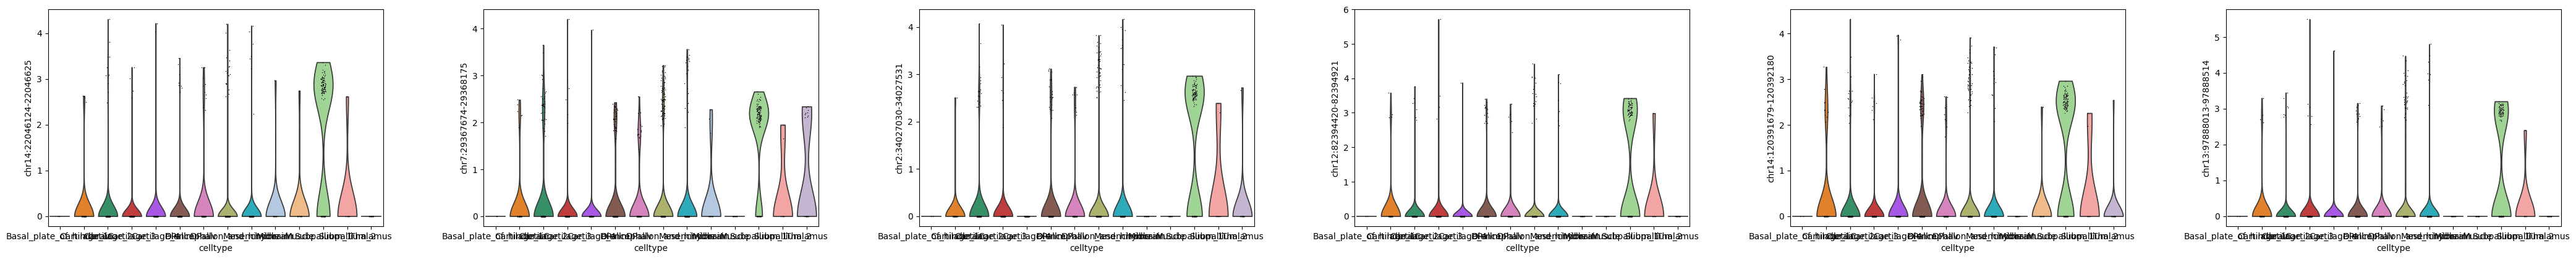

In [5]:
sc.pl.violin(adata,six_features,groupby="celltype")

In [6]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="celltype", method="wilcoxon")
sc.get.rank_genes_groups_df(adata, group="Subpallium_1").head(6)

,names,scores,logfoldchanges,pvals,pvals_adj
0,chr16:90521794-90522295,12.952329,3.918635,2.279336e-38,8.541812e-34
1,chr7:29367674-29368175,12.720687,3.743386,4.538520e-37,8.504053e-33
2,chr4:140069632-140070133,12.146551,3.389711,5.983716e-34,7.474659e-30
3,chr2:158610435-158610936,12.016644,3.386479,2.905344e-33,2.721944e-29
4,chr14:22046124-22046625,11.640465,5.331255,2.566147e-31,1.923327e-27
5,chr14:54995584-54996085,11.247001,3.219900,2.396026e-29,1.496518e-25


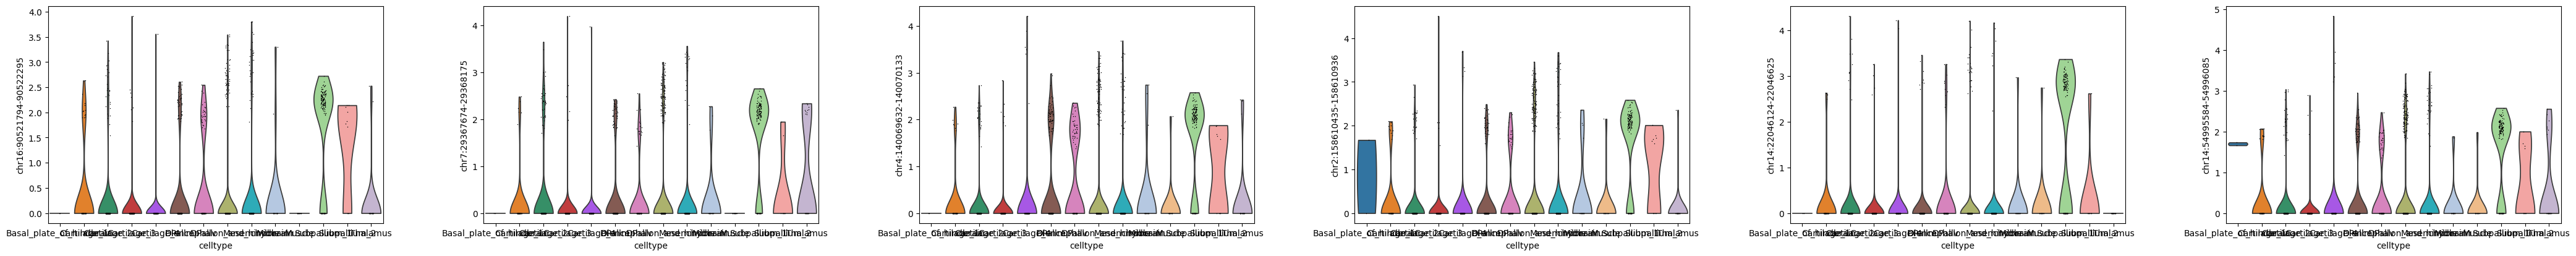

In [7]:
sc.pl.violin(adata,sc.get.rank_genes_groups_df(adata, group="Subpallium_1").head(6)['names'].tolist(),groupby="celltype")